# Clean Patch Experiment: Dual Transform Pipeline
Tests whether selecting the frequency patch from the raw unaugmented image
(as Chen et al. do) improves frequency branch performance vs our current approach
of selecting from the already-augmented image.

**The problem we are fixing:**
Current pipeline: `raw image → augmentation → select patch → FFT`
Chen et al. pipeline: `raw image → select patch → FFT` (no aug on patch)

**What this notebook does:**
Returns `(augmented_image, raw_image, label)` from the DataLoader.
Frequency branch uses `raw_image` for patch selection.
Spatial branch uses `augmented_image`.

**Baseline to beat:** 72.0% (v5 patch, no aug at all, 30 epochs)
**Target:** get close to 72% while keeping augmentations on for spatial branch.


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import os as _os

print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)}")


Device: cuda
GPU:    NVIDIA RTX PRO 4000 Blackwell


## 2. Dual-Transform Dataset

In [ ]:
from data.transforms import get_transforms

class DeepDetectDualTransform(Dataset):
    """
    Returns (augmented_image, raw_image, label) per sample.
    - augmented_image: full augmentation pipeline — for spatial branch
    - raw_image:       clean test transform only — for frequency branch patch selection
    """
    LABEL_MAP = {"real": 0, "fake": 1}

    def __init__(self, root, split="train",
                 aug_transform=None, clean_transform=None):
        self.root            = Path(root)
        self.split           = split
        self.aug_transform   = aug_transform
        self.clean_transform = clean_transform
        self.samples         = []
        self._load_samples()

    def _load_samples(self):
        for class_name, label in self.LABEL_MAP.items():
            class_dir = self.root / self.split / class_name
            with _os.scandir(class_dir) as it:
                for entry in it:
                    if entry.is_file() and entry.name.lower().endswith(
                        (".jpg", ".jpeg", ".png")):
                        self.samples.append((entry.path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        aug_image   = self.aug_transform(image)   if self.aug_transform   else image
        clean_image = self.clean_transform(image) if self.clean_transform else image
        return aug_image, clean_image, label


def get_dual_loaders(deepdetect_root, image_size=224, batch_size=64,
                     num_workers=4, val_split=0.15, seed=42):
    aug_tf = get_transforms("train", image_size=image_size,
                             jpeg_aug=True, blur_aug=True, noise_aug=True,
                             recompression_aug=True, mixed_aug=True,
                             mixed_aug_prob=0.3)
   
    clean_tf = get_transforms(
        "train",
        image_size        = image_size,
        jpeg_aug          = False,
        blur_aug          = False,
        noise_aug         = False,
        recompression_aug = False,
        mixed_aug         = False,
    )

    full_train = DeepDetectDualTransform(
        deepdetect_root, split="train",
        aug_transform=aug_tf, clean_transform=clean_tf)
    test_ds = DeepDetectDualTransform(
        deepdetect_root, split="test",
        aug_transform=clean_tf, clean_transform=clean_tf)

    n_total = len(full_train)
    n_val   = int(n_total * val_split)
    n_train = n_total - n_val
    generator = torch.Generator().manual_seed(seed)
    from torch.utils.data import random_split, Subset

    train_ds, val_indices = random_split(
        full_train, [n_train, n_val], generator=generator)

    clean_full = DeepDetectDualTransform(
        deepdetect_root, split="train",
        aug_transform=clean_tf, clean_transform=clean_tf)
    val_ds = Subset(clean_full, val_indices.indices)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")
    return train_loader, val_loader, test_loader
DEEPDETECT_ROOT = "../data/raw/deep_detect/data"
train_loader, val_loader, test_loader = get_dual_loaders(DEEPDETECT_ROOT)


Train: 76,848  Val: 13,561  Test: 21,776


## 3. Verify Dual Transform

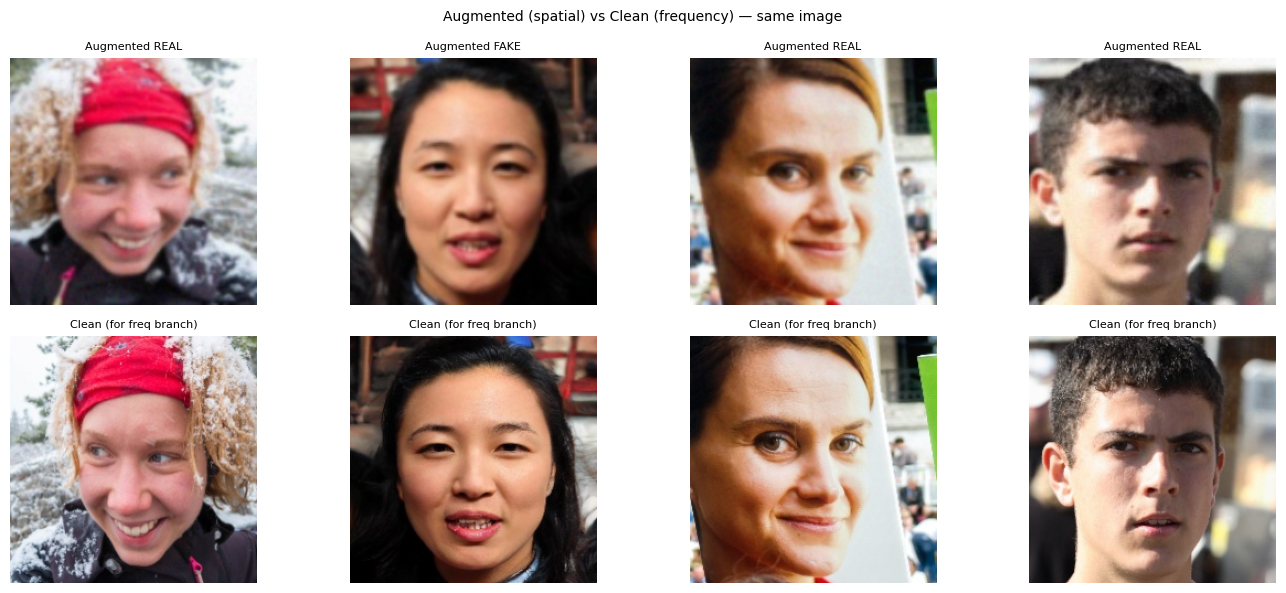

Pixel difference (should be nonzero): 0.6827757954597473


In [ ]:
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

aug_batch, clean_batch, labels = next(iter(train_loader))

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(t):
    return (t * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    axes[0][i].imshow(denorm(aug_batch[i]).permute(1,2,0).numpy())
    axes[0][i].set_title(f"Augmented {'REAL' if labels[i]==0 else 'FAKE'}", fontsize=8)
    axes[0][i].axis("off")
    axes[1][i].imshow(denorm(clean_batch[i]).permute(1,2,0).numpy())
    axes[1][i].set_title("Clean (for freq branch)", fontsize=8)
    axes[1][i].axis("off")

plt.suptitle("Augmented (spatial) vs Clean (frequency) — same image", fontsize=10)
plt.tight_layout()
plt.show()
print("Pixel difference (should be nonzero):",
      (aug_batch - clean_batch).abs().mean().item())


## 4. Frequency Branch Using Clean Patches

In [ ]:
from models.frequency_branch import SRMFilterLayer
from utils.metrics import binary_accuracy

IMAGENET_MEAN_GPU = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD_GPU  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

def rgb_to_hsv_batch(rgb):
    r, g, b = rgb[:,0], rgb[:,1], rgb[:,2]
    maxc = rgb.max(1).values
    minc = rgb.min(1).values
    v    = maxc
    s    = torch.where(maxc != 0, (maxc - minc) / (maxc + 1e-8),
                       torch.zeros_like(maxc))
    rc   = (maxc - r) / (maxc - minc + 1e-8)
    gc   = (maxc - g) / (maxc - minc + 1e-8)
    bc   = (maxc - b) / (maxc - minc + 1e-8)
    h    = torch.where(r == maxc, bc - gc,
           torch.where(g == maxc, 2.0 + rc - bc, 4.0 + gc - rc))
    h    = (h / 6.0) % 1.0
    return h, s, v

def select_patch_v5_batch(images, patch_size=56):
    B, C, H, W = images.shape
    patch_size = min(patch_size, H, W)
    if patch_size == H and patch_size == W:
        return images
    device = images.device
    mean_d = IMAGENET_MEAN_GPU.to(device)
    std_d  = IMAGENET_STD_GPU.to(device)
    img_denorm = (images * std_d + mean_d).clamp(0, 1)
    h, s, v    = rgb_to_hsv_batch(img_denorm)
    skin_mask  = ((h >= 0.0) & (h <= 0.1) & (s >= 0.1) &
                  (s <= 0.7) & (v >= 0.2)).float().unsqueeze(1)
    gray   = images.mean(dim=1, keepdim=True)
    kernel = torch.ones(1, 1, patch_size, patch_size, device=device) / (patch_size**2)
    lm     = F.conv2d(gray,      kernel, padding=0)
    lmsq   = F.conv2d(gray**2,   kernel, padding=0)
    local_var  = (lmsq - lm**2).squeeze(1)
    sk_kernel  = torch.ones(1, 1, patch_size, patch_size, device=device) / (patch_size**2)
    local_skin = F.conv2d(skin_mask, sk_kernel, padding=0).squeeze(1)
    patches = []
    for i in range(B):
        sp = (local_skin[i] >= 0.3)
        if sp.any():
            vm = local_var[i].clone()
            vm[~sp] = float("inf")
            flat_idx = vm.argmin()
        else:
            flat_idx = local_var[i].argmin()
        top  = (flat_idx // local_var.shape[2]).item()
        left = (flat_idx  % local_var.shape[2]).item()
        patches.append(images[i, :, top:top+patch_size, left:left+patch_size])
    return torch.stack(patches)

def phase_fft(x, fftshift=True):
    spectrum = torch.fft.fft2(x.float())
    if fftshift:
        spectrum = torch.fft.fftshift(spectrum, dim=(-2,-1))
    log_mag = torch.log1p(torch.abs(spectrum))
    mean = log_mag.mean(dim=(-2,-1), keepdim=True)
    std  = log_mag.std(dim=(-2,-1), keepdim=True)
    log_mag = (log_mag - mean) / (std + 1e-8)
    phase = torch.angle(spectrum) / torch.pi
    return torch.cat([log_mag, phase], dim=1)


class FreqBranchCleanPatch(nn.Module):
    """
    Frequency branch that receives the clean raw image separately.
    Patch is selected from clean_image, not the augmented image.
    This is the Chen et al. approach adapted to our architecture.
    """
    def __init__(self, feature_dim=256):
        super().__init__()
        self.srm  = SRMFilterLayer()
        self.cnn  = nn.Sequential(
            nn.Conv2d(18, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(128, feature_dim)
        self.head = nn.Linear(feature_dim, 2)

    def forward(self, clean_images):
        """clean_images: raw unaugmented images from DataLoader"""
        patches = select_patch_v5_batch(clean_images, patch_size=56)
        x = self.srm(patches)
        x = phase_fft(x)
        x = self.cnn(x)
        x = self.gap(x).flatten(1)
        x = self.proj(x)
        return self.head(x)

## 5. Training Loop

In [ ]:
def train_clean_patch(model, cfg_epochs, train_loader, val_loader,
                      test_loader, device, exp_name):
    """
    Training loop for dual-transform experiment.
    DataLoader yields (aug_image, clean_image, label).
    Model receives clean_image for patch selection.
    """
    epochs    = cfg_epochs
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler    = GradScaler(enabled=device.type == "cuda")
    Path("../checkpoints").mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*65}")
    print(f"Experiment: {exp_name} | Epochs: {epochs}")
    print(f"Patch selected from: CLEAN raw image (Chen et al. approach)")
    print(f"Augmentations: ON for spatial branch (not used here), patch is clean")
    print(f"{'='*65}")

    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss, train_logits, train_labels = 0.0, [], []

        for aug_images, clean_images, labels in train_loader:
            # Frequency branch uses clean_images — patch from unaugmented image
            clean_images = clean_images.to(device)
            labels       = labels.to(device)
            optimizer.zero_grad()
            with autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = model(clean_images)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            train_logits.append(logits.detach().cpu())
            train_labels.append(labels.cpu())

        scheduler.step()
        train_acc = binary_accuracy(torch.cat(train_logits), torch.cat(train_labels))

        model.eval()
        val_logits, val_labels_list = [], []
        with torch.no_grad():
            for _, clean_images, labels in val_loader:
                val_logits.append(model(clean_images.to(device)).cpu())
                val_labels_list.append(labels)
        val_acc = binary_accuracy(torch.cat(val_logits), torch.cat(val_labels_list))

        print(f"Epoch {epoch+1:>3}/{epochs} | "
              f"train_loss={total_loss/len(train_loader):.4f} | "
              f"train_acc={train_acc:.1%} | val_acc={val_acc:.1%}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"../checkpoints/best_{exp_name}.pt")
            print(f"  -> Saved best val_acc={best_val_acc:.1%}")

    # Test evaluation
    model.load_state_dict(torch.load(f"../checkpoints/best_{exp_name}.pt",
                                     map_location=device))
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for _, clean_images, labels in test_loader:
            all_logits.append(model(clean_images.to(device)).cpu())
            all_labels.append(labels)
    acc = binary_accuracy(torch.cat(all_logits), torch.cat(all_labels))
    print(f"\nTest accuracy: {acc:.1%}")
    return acc

## 6. Run Experiment

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = FreqBranchCleanPatch().to(device)
acc    = train_clean_patch(model, 30, train_loader, val_loader,
                           test_loader, device, "clean_patch_chen_et_al")



Experiment: clean_patch_chen_et_al | Epochs: 30
Patch selected from: CLEAN raw image (Chen et al. approach)
Augmentations: ON for spatial branch (not used here), patch is clean
Epoch   1/30 | train_loss=0.6685 | train_acc=58.9% | val_acc=60.5%
  -> Saved best val_acc=60.5%
Epoch   2/30 | train_loss=0.6447 | train_acc=62.3% | val_acc=63.7%
  -> Saved best val_acc=63.7%
Epoch   3/30 | train_loss=0.6290 | train_acc=64.0% | val_acc=62.6%
Epoch   4/30 | train_loss=0.6184 | train_acc=65.1% | val_acc=65.3%
  -> Saved best val_acc=65.3%
Epoch   5/30 | train_loss=0.6079 | train_acc=65.9% | val_acc=66.4%
  -> Saved best val_acc=66.4%
Epoch   6/30 | train_loss=0.5987 | train_acc=66.8% | val_acc=67.6%
  -> Saved best val_acc=67.6%
Epoch   7/30 | train_loss=0.5916 | train_acc=67.5% | val_acc=65.8%
Epoch   8/30 | train_loss=0.5849 | train_acc=68.0% | val_acc=68.5%
  -> Saved best val_acc=68.5%
Epoch   9/30 | train_loss=0.5780 | train_acc=68.7% | val_acc=68.4%
Epoch  10/30 | train_loss=0.5741 | trai

## 7. Results

In [7]:
print("\n" + "="*60)
print("CLEAN PATCH EXPERIMENT — Chen et al. approach")
print("="*60)
print(f"  Baseline — v5 with aug (current approach):   63.2%")
print(f"  Baseline — v5 no aug:                        72.0%")
print(f"  Clean patch (raw image), with aug pipeline:  {acc:.1%}")
print("="*60)

if acc >= 0.720:
    print("SUCCESS — clean patch matches no-aug ceiling.")
    print("Implement dual-transform pipeline in codebase.")
elif acc >= 0.680:
    print("IMPROVEMENT — clean patch helps significantly.")
    print("Worth implementing — closes most of the aug penalty.")
elif acc >= 0.632:
    print("MODEST — small improvement over current augmented approach.")
    print("Consider implementing alongside other improvements.")
else:
    print("NO IMPROVEMENT — augmentation is not the main issue.")
    print("The patch quality problem (dark corners) is more fundamental.")



CLEAN PATCH EXPERIMENT — Chen et al. approach
  Baseline — v5 with aug (current approach):   63.2%
  Baseline — v5 no aug:                        72.0%
  Clean patch (raw image), with aug pipeline:  74.2%
SUCCESS — clean patch matches no-aug ceiling.
Implement dual-transform pipeline in codebase.


In [ ]:
# Run 2: Clean patch + v5 + phase + C1 deeper cleaner

class ResidualBlock(nn.Module):
    def __init__(self, channels=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, 16, 3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
    def forward(self, x):
        return x + self.block(x)

class CleanerC1(nn.Module):
    def __init__(self):
        super().__init__()
        self.perception = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.perc_head         = nn.Linear(32, 3)
        self.filter_clean      = ResidualBlock(3)
        self.filter_blurry     = ResidualBlock(3)
        self.filter_compressed = ResidualBlock(3)

    def forward(self, x):
        w = F.softmax(self.perc_head(
            self.perception(x).flatten(1)), dim=1)
        out_c = self.filter_clean(x)
        out_b = self.filter_blurry(x)
        out_k = self.filter_compressed(x)
        blended = (w[:,0:1].unsqueeze(-1).unsqueeze(-1) * out_c +
                   w[:,1:2].unsqueeze(-1).unsqueeze(-1) * out_b +
                   w[:,2:3].unsqueeze(-1).unsqueeze(-1) * out_k)
        return x + blended


class FreqBranchCleanPatchWithCleaner(nn.Module):
    """Clean patch + v5 + phase FFT + C1 deeper cleaner."""
    def __init__(self, feature_dim=256):
        super().__init__()
        self.cleaner = CleanerC1()
        self.srm     = SRMFilterLayer()
        self.cnn     = nn.Sequential(
            nn.Conv2d(18, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(128, feature_dim)
        self.head = nn.Linear(feature_dim, 2)

    def forward(self, clean_images):
        patches = select_patch_v5_batch(clean_images, patch_size=56)
        patches = self.cleaner(patches)
        x = self.srm(patches)
        x = phase_fft(x)
        x = self.cnn(x)
        x = self.gap(x).flatten(1)
        x = self.proj(x)
        return self.head(x)

In [9]:
model_with_cleaner = FreqBranchCleanPatchWithCleaner().to(device)
acc_with_cleaner   = train_clean_patch(
    model_with_cleaner, 30, train_loader, val_loader,
    test_loader, device, "clean_patch_v5_phase_c1"
)


Experiment: clean_patch_v5_phase_c1 | Epochs: 30
Patch selected from: CLEAN raw image (Chen et al. approach)
Augmentations: ON for spatial branch (not used here), patch is clean
Epoch   1/30 | train_loss=0.6686 | train_acc=58.7% | val_acc=60.0%
  -> Saved best val_acc=60.0%
Epoch   2/30 | train_loss=0.6372 | train_acc=63.0% | val_acc=58.5%
Epoch   3/30 | train_loss=0.6213 | train_acc=64.6% | val_acc=61.4%
  -> Saved best val_acc=61.4%
Epoch   4/30 | train_loss=0.6120 | train_acc=65.7% | val_acc=66.5%
  -> Saved best val_acc=66.5%
Epoch   5/30 | train_loss=0.6035 | train_acc=66.2% | val_acc=65.9%
Epoch   6/30 | train_loss=0.6010 | train_acc=66.6% | val_acc=65.4%
Epoch   7/30 | train_loss=0.5927 | train_acc=67.4% | val_acc=67.0%
  -> Saved best val_acc=67.0%
Epoch   8/30 | train_loss=0.5923 | train_acc=67.4% | val_acc=65.7%
Epoch   9/30 | train_loss=0.5894 | train_acc=67.6% | val_acc=65.6%
Epoch  10/30 | train_loss=0.5875 | train_acc=68.1% | val_acc=65.7%
Epoch  11/30 | train_loss=0.583

In [10]:
print("\n" + "="*60)
print("CLEAN PATCH EXPERIMENT — Final Comparison")
print("="*60)
print(f"  v5 with aug (current):              63.2%")
print(f"  v5 no aug:                          72.0%")
print(f"  Clean patch, no cleaner:            {acc:.1%}")
print(f"  Clean patch + C1 cleaner:           {acc_with_cleaner:.1%}")
print("="*60)


CLEAN PATCH EXPERIMENT — Final Comparison
  v5 with aug (current):              63.2%
  v5 no aug:                          72.0%
  Clean patch, no cleaner:            74.2%
  Clean patch + C1 cleaner:           73.0%


In [ ]:
# Run 3: Old perception + old cleaner (original DegradationAwareCleaner)
from models.cleaner import DegradationAwareCleaner

class FreqBranchOrigCleaner(nn.Module):
    """Clean patch + v5 + phase + original cleaner (old perception + single Conv2d)."""
    def __init__(self, feature_dim=256):
        super().__init__()
        self.cleaner = DegradationAwareCleaner(n_filters=3)
        self.srm     = SRMFilterLayer()
        self.cnn     = nn.Sequential(
            nn.Conv2d(18, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(128, feature_dim)
        self.head = nn.Linear(feature_dim, 2)

    def forward(self, clean_images):
        patches = select_patch_v5_batch(clean_images, patch_size=56)
        patches = self.cleaner(patches)
        x = self.srm(patches)
        x = phase_fft(x)
        x = self.cnn(x)
        x = self.gap(x).flatten(1)
        x = self.proj(x)
        return self.head(x)

model_orig = FreqBranchOrigCleaner().to(device)
acc_orig   = train_clean_patch(
    model_orig, 30, train_loader, val_loader,
    test_loader, device, "clean_patch_old_perc_old_cleaner"
)


Experiment: clean_patch_old_perc_old_cleaner | Epochs: 30
Patch selected from: CLEAN raw image (Chen et al. approach)
Augmentations: ON for spatial branch (not used here), patch is clean
Epoch   1/30 | train_loss=0.6710 | train_acc=58.2% | val_acc=57.3%
  -> Saved best val_acc=57.3%
Epoch   2/30 | train_loss=0.6413 | train_acc=62.6% | val_acc=64.8%
  -> Saved best val_acc=64.8%
Epoch   3/30 | train_loss=0.6275 | train_acc=64.3% | val_acc=64.7%
Epoch   4/30 | train_loss=0.6149 | train_acc=65.3% | val_acc=65.2%
  -> Saved best val_acc=65.2%
Epoch   5/30 | train_loss=0.6059 | train_acc=66.1% | val_acc=66.9%
  -> Saved best val_acc=66.9%
Epoch   6/30 | train_loss=0.5969 | train_acc=67.0% | val_acc=63.7%
Epoch   7/30 | train_loss=0.5885 | train_acc=67.9% | val_acc=67.3%
  -> Saved best val_acc=67.3%
Epoch   8/30 | train_loss=0.5825 | train_acc=68.3% | val_acc=68.4%
  -> Saved best val_acc=68.4%
Epoch   9/30 | train_loss=0.5754 | train_acc=69.1% | val_acc=68.0%
Epoch  10/30 | train_loss=0.5

In [ ]:
# Run 4: New perception + old cleaner 
class NewPerceptionOldFilters(nn.Module):
    """C2 perception (3 layers + BN) with original single Conv2d filters."""
    def __init__(self):
        super().__init__()
        self.perception = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.perc_head         = nn.Linear(64, 3)
        self.filter_clean      = nn.Conv2d(3, 3, 3, padding=1)
        self.filter_blurry     = nn.Conv2d(3, 3, 3, padding=1)
        self.filter_compressed = nn.Conv2d(3, 3, 3, padding=1)

    def forward(self, x):
        w = F.softmax(self.perc_head(
            self.perception(x).flatten(1)), dim=1)
        out_c = self.filter_clean(x)
        out_b = self.filter_blurry(x)
        out_k = self.filter_compressed(x)
        blended = (w[:,0:1].unsqueeze(-1).unsqueeze(-1) * out_c +
                   w[:,1:2].unsqueeze(-1).unsqueeze(-1) * out_b +
                   w[:,2:3].unsqueeze(-1).unsqueeze(-1) * out_k)
        return x + blended

class FreqBranchNewPercOldFilters(nn.Module):
    """Clean patch + v5 + phase + new perception + old filters."""
    def __init__(self, feature_dim=256):
        super().__init__()
        self.cleaner = NewPerceptionOldFilters()
        self.srm     = SRMFilterLayer()
        self.cnn     = nn.Sequential(
            nn.Conv2d(18, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(128, feature_dim)
        self.head = nn.Linear(feature_dim, 2)

    def forward(self, clean_images):
        patches = select_patch_v5_batch(clean_images, patch_size=56)
        patches = self.cleaner(patches)
        x = self.srm(patches)
        x = phase_fft(x)
        x = self.cnn(x)
        x = self.gap(x).flatten(1)
        x = self.proj(x)
        return self.head(x)

model_new_perc_old = FreqBranchNewPercOldFilters().to(device)
acc_new_perc_old   = train_clean_patch(
    model_new_perc_old, 30, train_loader, val_loader,
    test_loader, device, "clean_patch_new_perc_old_cleaner"
)


Experiment: clean_patch_new_perc_old_cleaner | Epochs: 30
Patch selected from: CLEAN raw image (Chen et al. approach)
Augmentations: ON for spatial branch (not used here), patch is clean
Epoch   1/30 | train_loss=0.6720 | train_acc=58.2% | val_acc=61.6%
  -> Saved best val_acc=61.6%
Epoch   2/30 | train_loss=0.6375 | train_acc=63.1% | val_acc=63.1%
  -> Saved best val_acc=63.1%
Epoch   3/30 | train_loss=0.6209 | train_acc=64.9% | val_acc=65.6%
  -> Saved best val_acc=65.6%
Epoch   4/30 | train_loss=0.6077 | train_acc=65.9% | val_acc=66.9%
  -> Saved best val_acc=66.9%
Epoch   5/30 | train_loss=0.5964 | train_acc=67.1% | val_acc=67.3%
  -> Saved best val_acc=67.3%
Epoch   6/30 | train_loss=0.5876 | train_acc=67.9% | val_acc=65.6%
Epoch   7/30 | train_loss=0.5814 | train_acc=68.5% | val_acc=69.4%
  -> Saved best val_acc=69.4%
Epoch   8/30 | train_loss=0.5747 | train_acc=69.0% | val_acc=67.4%
Epoch   9/30 | train_loss=0.5687 | train_acc=69.3% | val_acc=68.6%
Epoch  10/30 | train_loss=0.5

In [ ]:
# Run 5: New perception + deep cleaner (C3 — full stronger cleaner) 
class CleanerC3Full(nn.Module):
    """C3: deeper perception (3 layers + BN) + residual block filters."""
    def __init__(self):
        super().__init__()
        self.perception = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.perc_head         = nn.Linear(64, 3)
        self.filter_clean      = ResidualBlock(3)
        self.filter_blurry     = ResidualBlock(3)
        self.filter_compressed = ResidualBlock(3)

    def forward(self, x):
        w = F.softmax(self.perc_head(
            self.perception(x).flatten(1)), dim=1)
        out_c = self.filter_clean(x)
        out_b = self.filter_blurry(x)
        out_k = self.filter_compressed(x)
        blended = (w[:,0:1].unsqueeze(-1).unsqueeze(-1) * out_c +
                   w[:,1:2].unsqueeze(-1).unsqueeze(-1) * out_b +
                   w[:,2:3].unsqueeze(-1).unsqueeze(-1) * out_k)
        return x + blended

class FreqBranchC3(nn.Module):
    """Clean patch + v5 + phase + C3 (new perception + deep filters)."""
    def __init__(self, feature_dim=256):
        super().__init__()
        self.cleaner = CleanerC3Full()
        self.srm     = SRMFilterLayer()
        self.cnn     = nn.Sequential(
            nn.Conv2d(18, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(128, feature_dim)
        self.head = nn.Linear(feature_dim, 2)

    def forward(self, clean_images):
        patches = select_patch_v5_batch(clean_images, patch_size=56)
        patches = self.cleaner(patches)
        x = self.srm(patches)
        x = phase_fft(x)
        x = self.cnn(x)
        x = self.gap(x).flatten(1)
        x = self.proj(x)
        return self.head(x)

model_c3 = FreqBranchC3().to(device)
acc_c3   = train_clean_patch(
    model_c3, 30, train_loader, val_loader,
    test_loader, device, "clean_patch_new_perc_deep_cleaner"
)


Experiment: clean_patch_new_perc_deep_cleaner | Epochs: 30
Patch selected from: CLEAN raw image (Chen et al. approach)
Augmentations: ON for spatial branch (not used here), patch is clean
Epoch   1/30 | train_loss=0.6654 | train_acc=59.2% | val_acc=56.5%
  -> Saved best val_acc=56.5%
Epoch   2/30 | train_loss=0.6387 | train_acc=62.6% | val_acc=58.6%
  -> Saved best val_acc=58.6%
Epoch   3/30 | train_loss=0.6277 | train_acc=63.7% | val_acc=65.1%
  -> Saved best val_acc=65.1%
Epoch   4/30 | train_loss=0.6185 | train_acc=64.7% | val_acc=62.9%
Epoch   5/30 | train_loss=0.6106 | train_acc=65.7% | val_acc=65.5%
  -> Saved best val_acc=65.5%
Epoch   6/30 | train_loss=0.6084 | train_acc=66.0% | val_acc=67.1%
  -> Saved best val_acc=67.1%
Epoch   7/30 | train_loss=0.6024 | train_acc=66.5% | val_acc=66.9%
Epoch   8/30 | train_loss=0.5972 | train_acc=67.0% | val_acc=63.9%
Epoch   9/30 | train_loss=0.5895 | train_acc=67.8% | val_acc=68.2%
  -> Saved best val_acc=68.2%
Epoch  10/30 | train_loss=0.

In [14]:
print("\n" + "="*65)
print("CLEANER ABLATION — Correct Pipeline (clean patch, spatial aug)")
print("="*65)
print(f"  No cleaner                              {acc:.1%}")
print(f"  Old perception + deep filters (C1)      {acc_with_cleaner:.1%}")
print(f"  Old perception + old filters (original) {acc_orig:.1%}")
print(f"  New perception + old filters            {acc_new_perc_old:.1%}")
print(f"  New perception + deep filters (C3)      {acc_c3:.1%}")
print("="*65)


CLEANER ABLATION — Correct Pipeline (clean patch, spatial aug)
  No cleaner                              74.2%
  Old perception + deep filters (C1)      73.0%
  Old perception + old filters (original) 75.0%
  New perception + old filters            74.2%
  New perception + deep filters (C3)      72.8%
